# Auxiliary | Robustness checks {#sec-robustness-checks}

We verify that the key qualitative finding — social learning (two-agent model) converges faster than individual learning (single-agent model), with the speedup growing with observational uncertainty — is robust to the choice of learning rate $\alpha$ and convergence threshold $\varepsilon$.

All checks use the medium state uncertainty case ($p_A = 0.58$, $p_B = 0.42$), which shows the richest dynamics including multiple critical transitions. Robustness of this case implies robustness for higher and lower state uncertainty values.

We focus on model-based agents (deterministic replicator dynamics), which are the primary model of the paper.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D
from collections import namedtuple

from _code.UncertainDecisionProblem import (
    SingleAgentUncertainDecisionProblem, TwoAgentUncertainDecisionProblem)
from _code.LearningDynamics import LearningAgents
from _code.SimulationScripts import (
    create_consistent_linspace, create_inital_lhs,
    compute_trajectories, obtain_noise_variation,
    final_rewards_Rki, collective_intelligence)

### Shared parameters {.unnumbered}

We use the same observational uncertainty grid as the main results. For the convergence-threshold check we additionally use a coarser grid of 21 points (no caching layer is applied there, so fewer points keeps runtime manageable).

In [2]:
lowlevel_datadictionary = "/Users/wolf/Downloads/L2SocialData"
highlevel_datadictionary = "./_data"
ddirs = dict(lowlevel_ddir=lowlevel_datadictionary,
             highlevel_ddir=highlevel_datadictionary)

probabilityA   = 0.58   # medium state uncertainty: p_B = 0.42
likelydistance = 0.5

noise_levels        = create_consistent_linspace(0.01, 4.0, 81)   # full grid (α check)
noise_levels_coarse = create_consistent_linspace(0.01, 4.0, 21)   # coarse grid (ε check)

alpha_values   = [0.125, 0.25, 0.5]       # learning rates; baseline = 0.25
epsilon_values = [10e-6, 10e-7, 10e-8]       # convergence thresholds; baseline = 1e-6 (= 10e-7 in code)

### Helper: plot convergence-time curve {.unnumbered}

In [3]:
COLOR_SINGLE = "#0072B2"  # blue — single-agent environment
COLOR_SOCIAL = "#D55E00"  # vermillion — two-agent environment

def _plot_band(Onk, noise_levels, color, ax):
    q1, med, q3 = np.percentile(Onk, [5, 50, 95], axis=1)
    ax.fill_between(noise_levels, q1, q3, color=color, alpha=0.4)
    ax.plot(noise_levels, med, '-', color=color)
    ax.set_ylim(10, 2750)

def plot_convergence(NoiVar, noise_levels, ax, maxT=5000):
    kw = dict(noise_levels=noise_levels, ax=ax)
    _plot_band(NoiVar.sa_Tnk, color=COLOR_SINGLE, **kw)
    _plot_band(NoiVar.ta_Tnk, color=COLOR_SOCIAL, **kw)
    ax.set_yscale('log')
    ax.set_xlim(-0.05, max(noise_levels) + 0.05)
    ax.xaxis.set_minor_locator(MultipleLocator(0.2))
    ax.grid(True, which='major', axis='y', alpha=0.4)
    ax.set_xlabel('Observational uncertainty $\\sigma$')

def plot_outperformance(NoiVar, noise_levels, ax):
    ci = collective_intelligence(NoiVar.ta_Rnki.mean(-1), NoiVar.sa_Rnki.mean(-1))
    # q1, med, q3 = np.percentile(ci, [5, 50, 95], axis=1)
    # ax.fill_between(noise_levels, q1, q3, color='purple', alpha=0.4)
    ax.plot(noise_levels, ci.mean(-1), '.-', color='k')
    ax.axhline(0, color='gray', lw=0.8, ls='--')
    ax.set_xlim(-0.05, max(noise_levels) + 0.05)
    ax.xaxis.set_minor_locator(MultipleLocator(0.2))
    ax.grid(True, which='major', axis='y', alpha=0.4)
    ax.set_xlabel('Observational uncertainty $\\sigma$')
    ax.set_ylabel('Reward outperformance')

## Learning rate $\alpha$ {#sec-robustness-alpha}

We vary $\alpha \in \{0.125, 0.25, 0.5\}$ while keeping $\varepsilon = 10^{-6}$ (the baseline). The full 81-point noise grid is used. Results are cached via the existing hash-based infrastructure, so the $\alpha = 0.25$ baseline loads instantly and the two new values are computed once and stored.

In [4]:
def obtain_robustness_comparison_alpha(
        probabilityA, noise_levels, learning_rate,
        maxT=5000, n_initial=25,
        lowlevel_ddir='', highlevel_ddir=''):
    """Like obtain_noise_variation_comparison but with configurable learning_rate."""
    agentparams = dict(learning_rates=learning_rate)
    envparams   = dict(probabilityA=probabilityA, likelydistance=0.5)

    # Two-agent
    env  = TwoAgentUncertainDecisionProblem(noiselevel=0.5, **envparams)
    maei = LearningAgents(env, **agentparams)
    initXkioa_ta = create_inital_lhs(maei, n_initial)
    ta_Tnk, ta_Rnki, _ = obtain_noise_variation(
        TwoAgentUncertainDecisionProblem, noise_levels, envparams,
        LearningAgents, agentparams, initXkioa_ta, maxT=maxT,
        lowlevel_ddir=lowlevel_ddir, highlevel_ddir=highlevel_ddir)

    # Single-agent
    env  = SingleAgentUncertainDecisionProblem(noiselevel=0.5, **envparams)
    maei = LearningAgents(env, **agentparams)
    initXkioa_sa = create_inital_lhs(maei, n_initial)
    sa_Tnk, sa_Rnki, _ = obtain_noise_variation(
        SingleAgentUncertainDecisionProblem, noise_levels, envparams,
        LearningAgents, agentparams, initXkioa_sa, maxT=maxT,
        lowlevel_ddir=lowlevel_ddir, highlevel_ddir=highlevel_ddir)

    NoiseVariation = namedtuple('NoiseVariation', ['ta_Tnk', 'sa_Tnk', 'ta_Rnki', 'sa_Rnki'])
    return NoiseVariation(ta_Tnk=ta_Tnk, sa_Tnk=sa_Tnk, ta_Rnki=ta_Rnki, sa_Rnki=sa_Rnki)

In [5]:
#| output: asis
print("\\begin{OutputCode}") #| hide_line
alpha_results = {}
for alpha in alpha_values:
    print(f"\n=== alpha = {alpha} ===")
    alpha_results[alpha] = obtain_robustness_comparison_alpha(
        probabilityA=probabilityA,
        noise_levels=noise_levels,
        learning_rate=alpha,
        **ddirs)
print("\\end{OutputCode}") #| hide_line

\begin{OutputCode}

=== alpha = 0.125 ===
Loading noise variation: ./_data/NOISEVARIATION_TwoAgentUncertainDecisionProblem_probabilityA0.58_likelydistance0.5_LearningAgents_learning_rates0.125_initalX12842151645801287464_maxT5000_Noises7752999609125433264.npz
Loading noise variation: ./_data/NOISEVARIATION_SingleAgentUncertainDecisionProblem_probabilityA0.58_likelydistance0.5_LearningAgents_learning_rates0.125_initalX7794212447693859915_maxT5000_Noises7752999609125433264.npz

=== alpha = 0.25 ===
Loading noise variation: ./_data/NOISEVARIATION_TwoAgentUncertainDecisionProblem_probabilityA0.58_likelydistance0.5_LearningAgents_learning_rates0.25_initalX12842151645801287464_maxT5000_Noises7752999609125433264.npz
Loading noise variation: ./_data/NOISEVARIATION_SingleAgentUncertainDecisionProblem_probabilityA0.58_likelydistance0.5_LearningAgents_learning_rates0.25_initalX7794212447693859915_maxT5000_Noises7752999609125433264.npz

=== alpha = 0.5 ===
Loading noise variation: ./_data/NOISEVAR

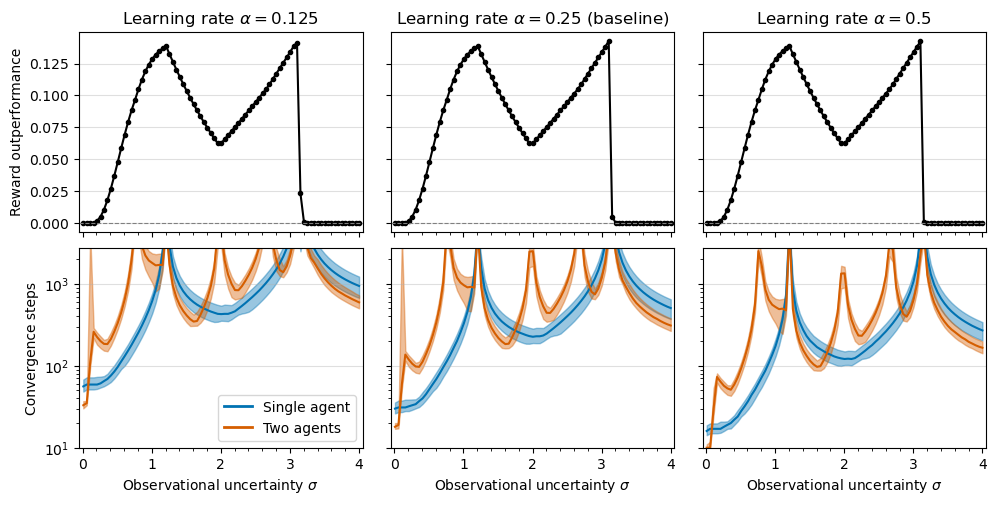

In [6]:
#| fig-cap: "Robustness to learning rate $\\alpha$. Top row: reward outperformance shape (purple, median $\\pm$5–95th percentile). Bottom row: convergence timescales for single-agent (blue) and two-agent (red) models. State uncertainty $p_B = 0.42$, model-based agents, $\\epsilon = 10^{-6}$."
fsf = 0.9
fig, axes = plt.subplots(2, 3, figsize=(fsf*13, fsf*6), sharey='row', sharex=True,
                         gridspec_kw=dict(hspace=0.08, wspace=0.1))

for col, alpha in enumerate(alpha_values):
    NoiVar = alpha_results[alpha]

    # Top: outperformance
    ax_top = axes[0, col]
    plot_outperformance(NoiVar, noise_levels, ax_top)
    ax_top.set_xlabel('')
    label = f'Learning rate $\\alpha = {alpha}$'
    if alpha == 0.25:
        label += ' (baseline)'
    ax_top.set_title(label)

    # Bottom: convergence steps
    ax_bot = axes[1, col]
    plot_convergence(NoiVar, noise_levels, ax_bot, maxT=5000)

# y-labels only on left column
for row, ylabel in enumerate(['Reward outperformance', 'Convergence steps']):
    axes[row, 0].set_ylabel(ylabel)
    for col in range(1, 3):
        axes[row, col].set_ylabel('')

# x-labels only on bottom row
for col in range(3):
    axes[0, col].set_xlabel('')

legend_elements = [
    Line2D([0], [0], color=COLOR_SINGLE, lw=2, label='Single agent'),
    Line2D([0], [0], color=COLOR_SOCIAL,  lw=2, label='Two agents')]
axes[1, 0].legend(handles=legend_elements, loc='lower right')

plt.savefig('./_figs/Robustness_LearningRate.png', dpi=300, bbox_inches='tight')

## Convergence threshold $\varepsilon$ {#sec-robustness-epsilon}

We vary $\varepsilon \in \{10^{-5}, 10^{-6}, 10^{-7}\}$ while keeping $\alpha = 0.25$ (the baseline). The baseline $\varepsilon = 10^{-6}$ corresponds to `tolerance=10e-7` in `compute_trajectories`.

Because $\varepsilon$ is not part of the existing cache-key scheme, we call `compute_trajectories` directly and use the coarser 21-point noise grid to keep computation time manageable. Results are **not** cached and will recompute on each notebook run.

In [7]:
def compute_convergence_with_tolerance(
        noise_levels, probabilityA, tolerance,
        learning_rate=0.25, maxT=5000, n_initial=10):
    """Compute convergence times and final rewards for both agent types with a given tolerance.
    Initial conditions are fixed (seed=42) and reused across noise levels."""
    agentparams = dict(learning_rates=learning_rate)
    envparams   = dict(probabilityA=probabilityA, likelydistance=0.5)

    results = {}
    for name, envclass in [('two',    TwoAgentUncertainDecisionProblem),
                             ('single', SingleAgentUncertainDecisionProblem)]:
        # Build initial conditions once from a reference environment
        env_ref  = envclass(noiselevel=0.5, **envparams)
        maei_ref = LearningAgents(env_ref, **agentparams)
        initXkioa = create_inital_lhs(maei_ref, n_initial)

        conv_times = []
        rewards    = []
        for ni, noise in enumerate(noise_levels):
            print(f"\r  [{name}] noise {ni+1}/{len(noise_levels)}", end='')
            env  = envclass(noiselevel=noise, **envparams)
            maei = LearningAgents(env, **agentparams)
            trjs, _ = compute_trajectories(maei, initXkioa, maxT=maxT, tolerance=tolerance)
            conv_times.append([len(t) for t in trjs])
            rewards.append(final_rewards_Rki(maei, trjs))
        print()
        results[name] = dict(Tnk=np.array(conv_times), Rnki=np.array(rewards))

    NoiseVariation = namedtuple('NoiseVariation', ['ta_Tnk', 'sa_Tnk', 'ta_Rnki', 'sa_Rnki'])
    return NoiseVariation(
        ta_Tnk=results['two']['Tnk'],    sa_Tnk=results['single']['Tnk'],
        ta_Rnki=results['two']['Rnki'],  sa_Rnki=results['single']['Rnki'])

In [8]:
#| output: false
epsilon_results = {}
for eps in epsilon_values:
    print(f"\n=== epsilon = {eps:.0e} ===")
    epsilon_results[eps] = compute_convergence_with_tolerance(
        noise_levels=noise_levels_coarse,
        probabilityA=probabilityA,
        tolerance=eps)


=== epsilon = 1e-05 ===
 [Computing policy trajectories]: 0.9
 [Computing policy trajectories]: 0.9
 [Computing policy trajectories]: 0.9
 [Computing policy trajectories]: 0.9
 [Computing policy trajectories]: 0.9
 [Computing policy trajectories]: 0.9
 [Computing policy trajectories]: 0.9
 [Computing policy trajectories]: 0.9
 [Computing policy trajectories]: 0.9
 [Computing policy trajectories]: 0.9
 [Computing policy trajectories]: 0.9
 [Computing policy trajectories]: 0.9
 [Computing policy trajectories]: 0.9
 [Computing policy trajectories]: 0.9
 [Computing policy trajectories]: 0.9
 [Computing policy trajectories]: 0.9
 [Computing policy trajectories]: 0.9
 [Computing policy trajectories]: 0.9
 [Computing policy trajectories]: 0.9
 [Computing policy trajectories]: 0.9
 [Computing policy trajectories]: 0.9

 [Computing policy trajectories]: 0.9
 [Computing policy trajectories]: 0.9
 [Computing policy trajectories]: 0.9
 [Computing policy trajectories]: 0.9
 [Computing policy traje

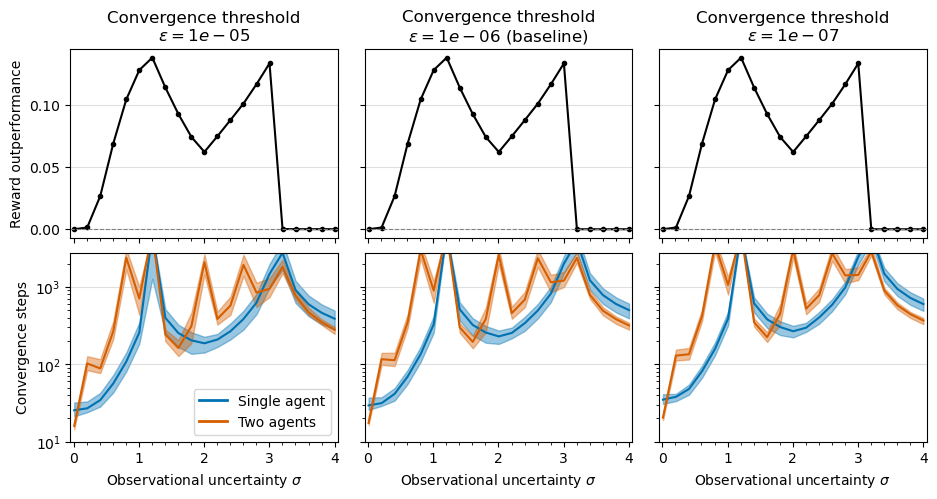

In [9]:
#| fig-cap: "Robustness to convergence threshold $\\epsilon$. Top row: reward outperformance shape. Bottom row: convergence timescales. Coarser 21-point noise grid; 10 initial conditions; state uncertainty $p_B = 0.42$, model-based agents, $\\alpha = 0.25$."
fsf = 0.85
fig, axes = plt.subplots(2, 3, figsize=(fsf*13, fsf*6), sharey='row', sharex=True,
                         gridspec_kw=dict(hspace=0.08, wspace=0.1))

for col, eps in enumerate(epsilon_values):
    NoiVar = epsilon_results[eps]

    # Top: outperformance
    ax_top = axes[0, col]
    plot_outperformance(NoiVar, noise_levels_coarse, ax_top)
    ax_top.set_xlabel('')
    label = f'Convergence threshold\n$\\varepsilon = {eps:.0e}$'
    if eps == 1e-6:
        label += ' (baseline)'
    ax_top.set_title(label)

    # Bottom: convergence steps
    ax_bot = axes[1, col]
    plot_convergence(NoiVar, noise_levels_coarse, ax_bot, maxT=5000)

# y-labels only on left column
for row, ylabel in enumerate(['Reward outperformance', 'Convergence steps']):
    axes[row, 0].set_ylabel(ylabel)
    for col in range(1, 3):
        axes[row, col].set_ylabel('')

# x-labels only on bottom row
for col in range(3):
    axes[0, col].set_xlabel('')

legend_elements = [
    Line2D([0], [0], color=COLOR_SINGLE, lw=2, label='Single agent'),
    Line2D([0], [0], color=COLOR_SOCIAL,  lw=2, label='Two agents')]
axes[1, 0].legend(handles=legend_elements, loc='lower right')

plt.savefig('./_figs/Robustness_ConvergenceThreshold.png', dpi=300, bbox_inches='tight')